
## **Breast Cancer Prediction**

## Objective

To develop an automated Machine Learning classification system that predicts the likelihood of breast cancer based on patient demographic, physiological, genetic, lifestyle, and clinical screening indicators.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix,classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [31]:
# Load Dataset
df = pd.read_csv(r'C:\Users\ACER SSD\Desktop\Python\Machine Learning\Project\data\breast_cancer_prediction.csv')

In [32]:
df.head()

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919


In [33]:
#Check Dataset Shape
df.shape

(10000, 23)

In [34]:
#Display All Columns
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Family_History', 'Smoking',
       'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy',
       'Menopause_Status', 'Genetic_Mutation', 'Tumor_Size_cm',
       'Lymph_Node_Involvement', 'Mammogram_Result', 'Biopsy_Result',
       'Cancer_Stage', 'Cancer', 'Blood_Pressure', 'Cholesterol', 'Diabetes',
       'Exercise_Days_Per_Week', 'Breastfeeding_History', 'Annual_Income_USD'],
      dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  str    
 3   BMI                     9700 non-null   float64
 4   Family_History          10000 non-null  str    
 5   Smoking                 10000 non-null  str    
 6   Alcohol_Consumption     9700 non-null   str    
 7   Physical_Activity       9700 non-null   str    
 8   Hormone_Therapy         9700 non-null   str    
 9   Menopause_Status        10000 non-null  str    
 10  Genetic_Mutation        10000 non-null  str    
 11  Tumor_Size_cm           9700 non-null   float64
 12  Lymph_Node_Involvement  10000 non-null  str    
 13  Mammogram_Result        10000 non-null  str    
 14  Biopsy_Result           10000 non-null  str    
 1

In [36]:
#Check Data Types
df.dtypes

Patient_ID                  int64
Age                         int64
Gender                        str
BMI                       float64
Family_History                str
Smoking                       str
Alcohol_Consumption           str
Physical_Activity             str
Hormone_Therapy               str
Menopause_Status              str
Genetic_Mutation              str
Tumor_Size_cm             float64
Lymph_Node_Involvement        str
Mammogram_Result              str
Biopsy_Result                 str
Cancer_Stage                  str
Cancer                      int64
Blood_Pressure              int64
Cholesterol                 int64
Diabetes                      str
Exercise_Days_Per_Week      int64
Breastfeeding_History         str
Annual_Income_USD           int64
dtype: object

In [37]:
#Statistical Summary
df.describe()

,Patient_ID,Age,BMI,Tumor_Size_cm,Cancer,Blood_Pressure,Cholesterol,Exercise_Days_Per_Week,Annual_Income_USD
count,10000.00000,10000.000000,9700.000000,9700.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,105000.50000,52.033800,27.051227,2.630334,0.193300,134.811100,214.071500,3.535200,82337.305000
std,2886.89568,18.789517,4.494501,1.589789,0.394906,26.174742,49.242034,2.282385,39102.629984
min,100001.00000,20.000000,11.100000,0.000000,0.000000,90.000000,130.000000,0.000000,15002.000000
25%,102500.75000,36.000000,24.000000,1.370000,0.000000,112.000000,172.000000,2.000000,48145.750000
50%,105000.50000,52.000000,27.000000,2.510000,0.000000,135.000000,213.000000,4.000000,81813.500000
75%,107500.25000,68.000000,30.100000,3.720000,0.000000,157.000000,257.000000,6.000000,116217.500000
max,110000.00000,84.000000,44.100000,9.880000,1.000000,180.000000,300.000000,7.000000,149996.000000


In [38]:
#Statistical Summary for categorical columns
df.describe(include='str').T

,count,unique,top,freq
Gender,10000,2,Female,9277
Family_History,10000,2,No,6979
Smoking,10000,2,No,7462
Alcohol_Consumption,9700,2,No,6319
Physical_Activity,9700,3,Moderate,4379
Hormone_Therapy,9700,2,No,7704
Menopause_Status,10000,2,Post,5509
Genetic_Mutation,10000,2,Negative,8542
Lymph_Node_Involvement,10000,2,No,7977
Mammogram_Result,10000,3,Normal,6481


In [39]:
#Remove ID
drop_cols = ["Patient_ID", "Biopsy_Result", "Cancer_Stage"]

df = df.drop(columns=drop_cols)

In [40]:
#Check Missing Values
df.isnull().sum()


Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64

## handle missing values inside the preprocessing pipeline

In [41]:
#Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [42]:
#Check target
print(df["Cancer"].value_counts())

Cancer
0    8067
1    1933
Name: count, dtype: int64


In [43]:
print(f'{(df["Cancer"].value_counts(normalize=True) * 100)}')

Cancer
0    80.67
1    19.33
Name: proportion, dtype: float64


## EDA

In [44]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(numeric_cols)

['Age', 'BMI', 'Tumor_Size_cm', 'Cancer', 'Blood_Pressure', 'Cholesterol', 'Exercise_Days_Per_Week', 'Annual_Income_USD']


In [45]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(categorical_cols)

['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy', 'Menopause_Status', 'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result', 'Diabetes', 'Breastfeeding_History']


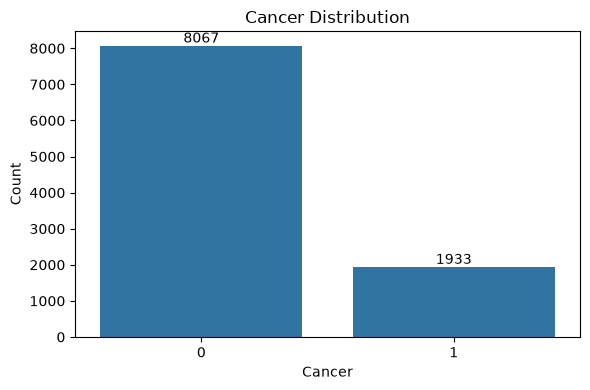

In [46]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Cancer")

plt.title("Cancer Distribution")
plt.xlabel("Cancer")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

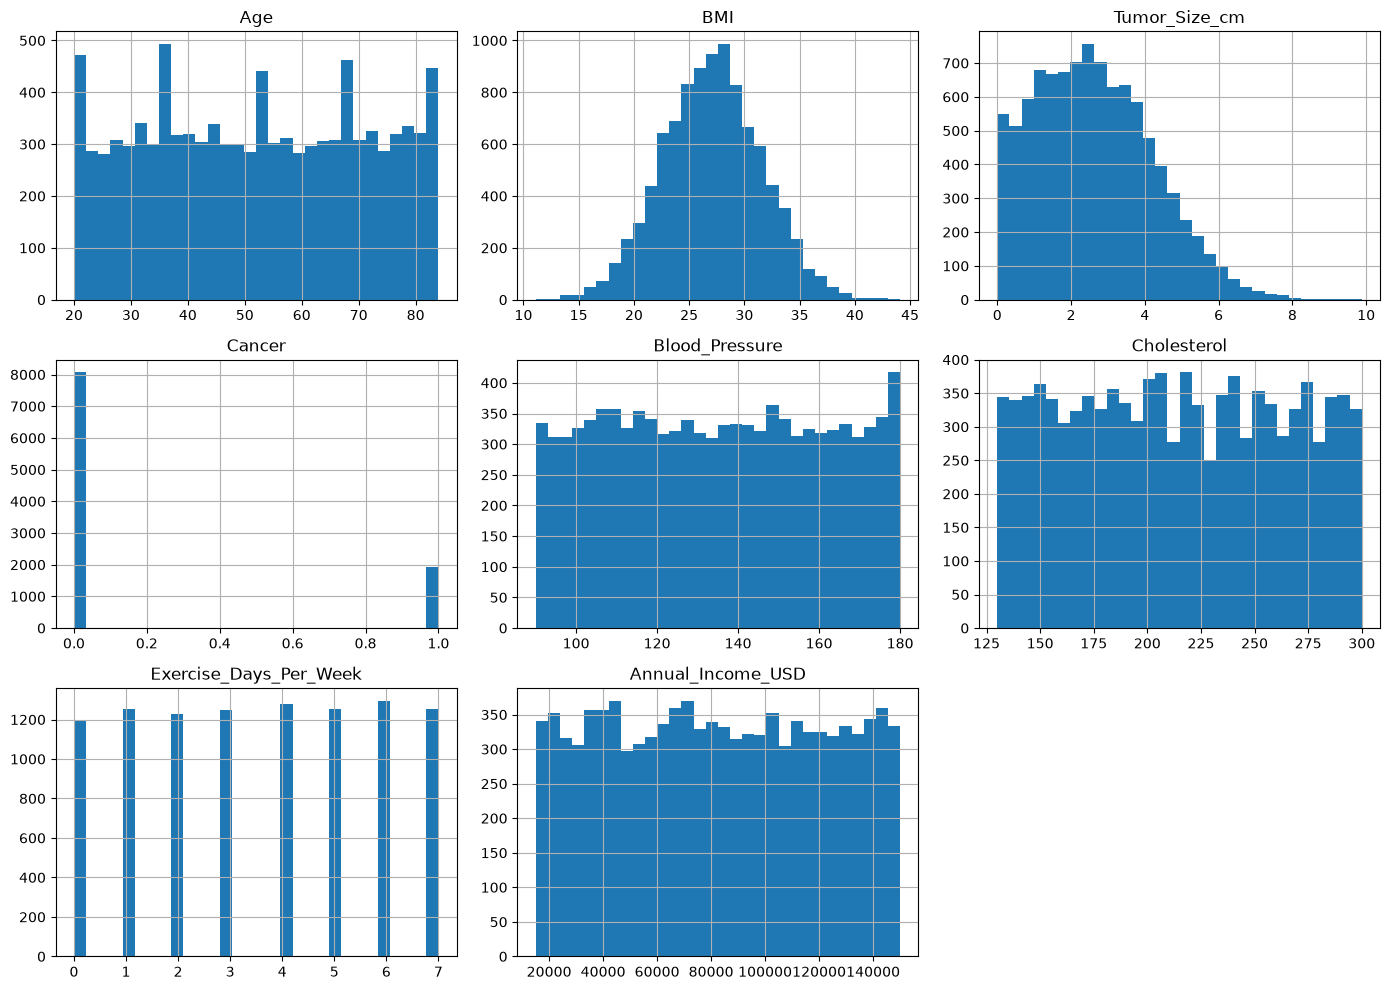

In [47]:
df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

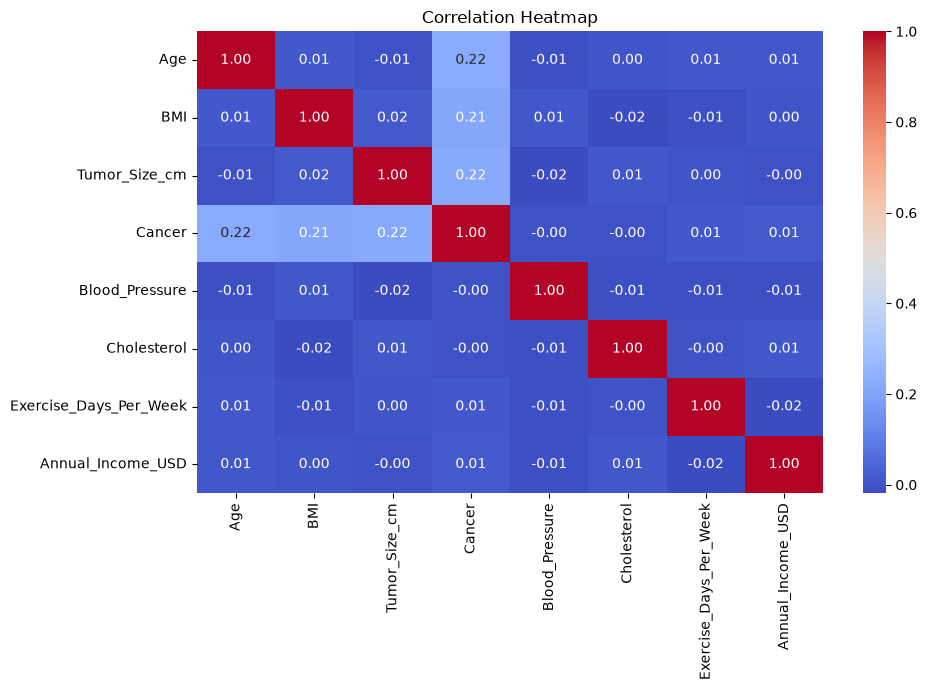

In [48]:
correlation = df[
    numeric_cols 
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [49]:
target_corr = (
    correlation["Cancer"]
    .drop("Cancer")
    .abs()
    .sort_values(ascending=False)
)

print(target_corr)

Age                       0.220109
Tumor_Size_cm             0.217819
BMI                       0.209494
Annual_Income_USD         0.013801
Exercise_Days_Per_Week    0.010148
Blood_Pressure            0.003849
Cholesterol               0.003437
Name: Cancer, dtype: float64


## Feature Engineering & Preprocessing

In [50]:
risk_cols = [
    "Family_History",
    "Smoking",
    "Alcohol_Consumption",
    "Hormone_Therapy",
    "Genetic_Mutation",
    "Diabetes"
]

# Convert risk factors to 0/1
risk_df = pd.DataFrame(index=df.index)

for col in risk_cols:
    if col == "Genetic_Mutation":
        risk_df[col] = df[col].map({
            "Positive": 1,
            "Negative": 0
        })
    else:
        risk_df[col] = df[col].map({
            "Yes": 1,
            "No": 0
        })

# Count available risk factors
df["Risk_Factor_Count"] = risk_df.sum(axis=1)

In [51]:
print(df["Risk_Factor_Count"].value_counts().sort_index())

Risk_Factor_Count
0.0    1957
1.0    3766
2.0    2798
3.0    1213
4.0     233
5.0      33
Name: count, dtype: int64


## Spliting Dataset

In [52]:
#Separate Features and Target
X = df.drop(columns=["Cancer"])
y = df["Cancer"]

In [53]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 20)
y shape: (10000,)


In [54]:
print("Target classes:")
print(y.value_counts())

Target classes:
Cancer
0    8067
1    1933
Name: count, dtype: int64


In [55]:
X.columns

Index(['Age', 'Gender', 'BMI', 'Family_History', 'Smoking',
       'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy',
       'Menopause_Status', 'Genetic_Mutation', 'Tumor_Size_cm',
       'Lymph_Node_Involvement', 'Mammogram_Result', 'Blood_Pressure',
       'Cholesterol', 'Diabetes', 'Exercise_Days_Per_Week',
       'Breastfeeding_History', 'Annual_Income_USD', 'Risk_Factor_Count'],
      dtype='str')

## Train-Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [57]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 20)
Testing data: (2000, 20)


## Identify Numerical and Categorical Features

In [58]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

In [59]:
print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'BMI', 'Tumor_Size_cm', 'Blood_Pressure', 'Cholesterol', 'Exercise_Days_Per_Week', 'Annual_Income_USD', 'Risk_Factor_Count']

Categorical Features:
['Gender', 'Family_History', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy', 'Menopause_Status', 'Genetic_Mutation', 'Lymph_Node_Involvement', 'Mammogram_Result', 'Diabetes', 'Breastfeeding_History']


## Create Preprocessing Pipeline

In [60]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [61]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [62]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Model Training

# Create the models

In [63]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [64]:
def train_and_evaluate(model, model_name):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Training
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Probability of Cancer = 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    cm = confusion_matrix(y_test, y_pred)

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

    return pipeline, result, cm

In [65]:
results = []
trained_models = {}
confusion_matrices = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    pipeline, result, cm = train_and_evaluate(
        model,
        model_name
    )

    trained_models[model_name] = pipeline
    results.append(result)
    confusion_matrices[model_name] = cm

    print("Completed.\n")

Training Logistic Regression...


Completed.

Training Decision Tree...
Completed.

Training Random Forest...
Completed.

Training Gradient Boosting...
Completed.



In [66]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9370,0.846154,0.824289,0.835079,0.976092
1,Decision Tree,0.9775,0.940722,0.943152,0.941935,0.964447
2,Random Forest,0.9735,0.974432,0.886305,0.928281,0.994033
3,Gradient Boosting,0.9940,1.000000,0.968992,0.984252,0.997572


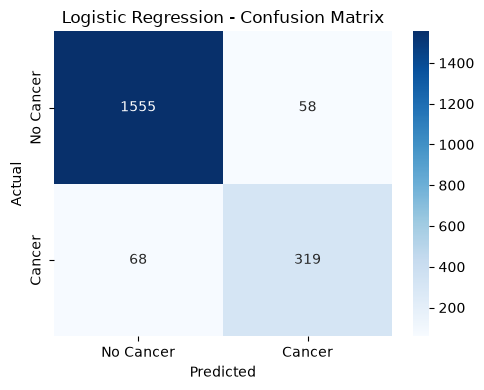

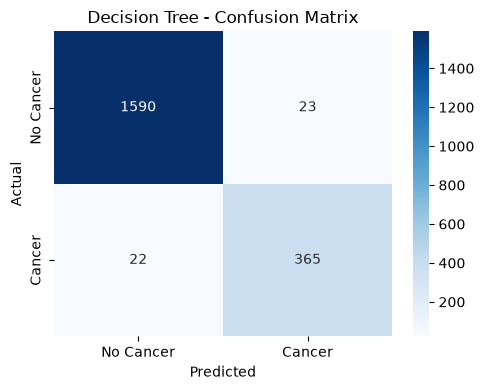

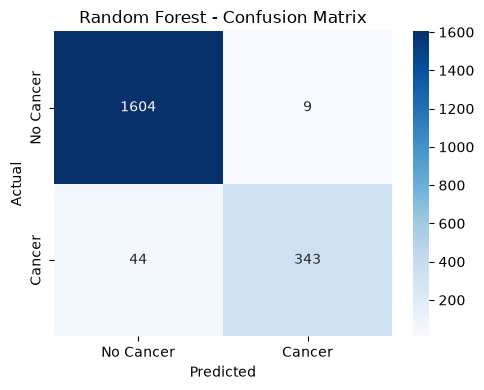

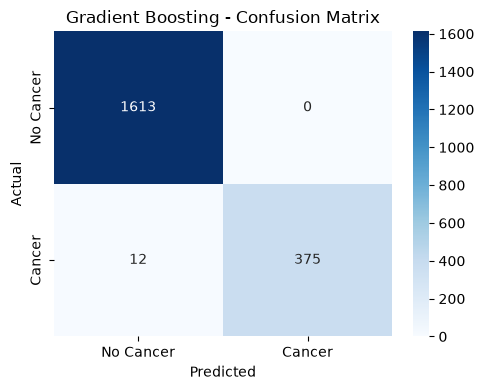

In [ ]:
for model_name, cm in confusion_matrices.items():

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Cancer", "Cancer"],yticklabels=["No Cancer", "Cancer"])

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [68]:
correlation = df[numeric_features + ["Cancer"]].corr()

target_corr = (
    correlation["Cancer"]
    .drop("Cancer")
    .sort_values(key=abs, ascending=False)
)

print(target_corr)

Risk_Factor_Count         0.314028
Age                       0.220109
Tumor_Size_cm             0.217819
BMI                       0.209494
Annual_Income_USD         0.013801
Exercise_Days_Per_Week    0.010148
Blood_Pressure           -0.003849
Cholesterol              -0.003437
Name: Cancer, dtype: float64


## Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

gb_pipeline = trained_models["Gradient Boosting"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    gb_pipeline,X,y,cv=cv,
    scoring=["accuracy","precision","recall","f1","roc_auc"],
    n_jobs=-1
)

In [70]:
cv_results_df = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1 Score": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

cv_results_df

,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.9940,1.0,0.968992,0.984252,0.996166
1,2,0.9955,1.0,0.976744,0.988235,0.996671
2,3,0.9950,1.0,0.974160,0.986911,0.999821
3,4,0.9915,1.0,0.955959,0.977483,0.996587
4,5,0.9920,1.0,0.958549,0.978836,0.997871


## Final Model evaluation

In [72]:
final_model = trained_models["Gradient Boosting"]

In [73]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

In [74]:
y_pred


array([0, 1, 0, ..., 0, 0, 0], shape=(2000,))

In [ ]:

print(
    classification_report(y_test,y_pred,
        target_names=["No Cancer", "Cancer"]
    )
)

              precision    recall  f1-score   support

   No Cancer       0.99      1.00      1.00      1613
      Cancer       1.00      0.97      0.98       387

    accuracy                           0.99      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [76]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

final_metrics

{'Accuracy': 0.994,
 'Precision': 1.0,
 'Recall': 0.9689922480620154,
 'F1 Score': 0.984251968503937,
 'ROC-AUC': 0.9975722128506914}

In [77]:
joblib.dump(final_model,"cancer_prediction_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [78]:
# Test that we saved pipeline can be loaded again
loaded_model = joblib.load("cancer_prediction_pipeline.pkl")

In [79]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Age','Gender','BMI',...,'Breastfeeding_History','Annual_Income_USD', 'Risk_Factor_Count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='